# Passo 1: Preparando as Ferramentas e Carregando os Dados
Antes de começar qualquer análise, precisamos trazer para o Python as ferramentas especializadas em planilhas e gráficos (chamadas de bibliotecas). O Python puro não sabe o que é um arquivo Excel ou CSV, por isso usamos esses "ajudantes":
* **Pandas (`pd`):** É o equivalente ao Excel. Ele lê a planilha e a transforma em uma tabela viva dentro da memória do computador.
* **NumPy (`np`):** Uma calculadora científica ultra-rápida para lidar com as fórmulas matemáticas.
* **Matplotlib e Seaborn:** Nossos designers gráficos, responsáveis por desenhar e colorir os gráficos de forma moderna.

> ⚠️ **Aviso Importante:** O Python precisa de algumas bibliotecas instaladas para manipular tabelas e gerar gráficos (Pandas, NumPy, Matplotlib e Seaborn). 
> 
> O código abaixo é **inteligente**: ele vai testar se você já tem essas ferramentas instaladas no seu computador.
> * Se você **não tiver**, ele vai baixar e instalar tudo automaticamente (pode demorar um minutinho na primeira vez).
> * Se você **já tiver**, ele vai ignorar a instalação e passar direto, sem desperdiçar seu tempo.
> 
> **Instrução:** Clique na célula de código abaixo e aperte `Shift + Enter` para rodar.

In [18]:
import sys

try:
    # 1. Tenta importar todas as ferramentas necessárias
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ Todas as bibliotecas já estão instaladas e prontas para o uso!\n")
    
    # 2. Carrega o arquivo CSV (como o Excel abriria)
    df = pd.read_csv('dataset.csv')
    print("📊 Arquivo 'dataset.csv' carregado com sucesso! Abaixo estão as primeiras linhas:")
    
    # Usamos o display() para forçar o Jupyter a mostrar a tabela mesmo dentro do bloco 'try'
    display(df.head())

except ModuleNotFoundError:
    # Se alguma biblioteca estiver faltando, avisa o usuário e inicia a instalação
    print("⚠️ Algumas bibliotecas não foram encontradas. Instalando ferramentas necessárias...")
    print("Por favor, aguarde o término do download (o asterisco [*] sumirá do lado esquerdo)...")
    
    # Executa o comando de instalação do terminal direto pelo notebook
    !pip install pandas numpy matplotlib seaborn
    
    print("\n✅ Instalação concluída com sucesso!")
    print("👉 Por favor, rode esta célula novamente para carregar os dados agora que tudo foi instalado.")

✅ Todas as bibliotecas já estão instaladas e prontas para o uso!

📊 Arquivo 'dataset.csv' carregado com sucesso! Abaixo estão as primeiras linhas:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


# 🧹 Passo 2: Tratamento de Valores Ausentes (Data Cleaning)
Antes de realizar qualquer cálculo estatístico, é fundamental garantir a qualidade dos dados. Foi identificada a existência de valores ausentes (*NaN/Null*) no atributo `HourSpendOnApp`. 

Para evitar distorções nas métricas e nos gráficos subsequentes, aplicamos uma estratégia clássica do Ciclo de Vida dos Dados: **preencher os valores nulos utilizando a mediana** da própria coluna.

In [19]:
# Verifica se existem valores nulos antes de tratar
nulos_antes = df['HourSpendOnApp'].isnull().sum()

if nulos_antes > 0:
    mediana_horas = df['HourSpendOnApp'].median()
    df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(mediana_horas)
    print(f"✨ Tratamento de Dados Concluído com Sucesso!")
    print(f"👉 Foram encontrados {nulos_antes} valores nulos em 'HourSpendOnApp', os quais foram preenchidos com a mediana ({mediana_horas}).")
else:
    print("✅ Nenhum valor nulo encontrado na coluna 'HourSpendOnApp'. Dados prontos!")

✨ Tratamento de Dados Concluído com Sucesso!
👉 Foram encontrados 255 valores nulos em 'HourSpendOnApp', os quais foram preenchidos com a mediana (3.0).


# Passo 3: Relatório Estatístico Completo (Métricas do Excel)
No Excel, para calcular média, mediana, desvio padrão, correlação, etc., teríamos que usar várias fórmulas como `=MÉDIA()`, `=MEDIANA()`, `=CORREL()` em células separadas. 

Aqui, o Python calcula tudo de uma vez para as colunas `HourSpendOnApp` (Horas Gastas no App) e `NumberOfDeviceRegistered` (Dispositivos Registrados).

### O que cada métrica significa para o negócio:
* **Média e Mediana:** Mostram o comportamento central do usuário. Se a mediana for menor que a média, significa que temos alguns usuários que passam tempo demais no app puxando a média para cima.
* **Moda:** O comportamento mais comum/frequente de todos.
* **Intervalo e Desvio Padrão:** Medem a dispersão. Um desvio padrão alto indica que os clientes têm comportamentos muito diferentes uns dos outros.
* **Covariância e Correlação com Churn:** Indicam se existe relação entre aquela métrica e o cliente cancelar o serviço (Churn). A correlação varia entre -1 e 1. Se for positiva, significa que quanto maior o número de dispositivos, por exemplo, maior tende a ser o cancelamento.

In [20]:
# Colunas que queremos analisar
colunas_analise = ['HourSpendOnApp', 'NumberOfDeviceRegistered']

# 1. Métricas básicas (Média, Mediana/Percentil 50, Percentil 25, Percentil 75, Min, Max)
estatisticas = df[colunas_analise].describe().loc[['mean', '50%', '25%', '75%', 'min', 'max']]
estatisticas.index = ['Média', 'Mediana (P50)', 'Percentil 25', 'Percentil 75', 'Mínimo', 'Máximo']

# 2. Calcular a Moda (ajustando caso haja mais de uma)
moda = df[colunas_analise].mode().iloc[0]
moda.name = 'Moda'
estatisticas = pd.concat([estatisticas, pd.DataFrame([moda])])

# 3. Calcular o Intervalo (Máximo - Mínimo)
intervalo = df[colunas_analise].max() - df[colunas_analise].min()
intervalo.name = 'Intervalo'
estatisticas = pd.concat([estatisticas, pd.DataFrame([intervalo])])

# 4. Calcular o Desvio Padrão
desvio_padrao = df[colunas_analise].std()
desvio_padrao.name = 'Desvio Padrão'
estatisticas = pd.concat([estatisticas, pd.DataFrame([desvio_padrao])])

# 5. Calcular Covariância com a coluna 'Churn'
cov_churn = df[colunas_analise].apply(lambda col: df['Churn'].cov(col))
cov_churn.name = 'Covariância com Churn'
estatisticas = pd.concat([estatisticas, pd.DataFrame([cov_churn])])

# 6. Calcular Correlação com a coluna 'Churn'
corr_churn = df[colunas_analise].apply(lambda col: df['Churn'].corr(col))
corr_churn.name = 'Correlação com Churn'
estatisticas = pd.concat([estatisticas, pd.DataFrame([corr_churn])])

# Exibir o relatório completo de métricas
print("--- RELATÓRIO DE MÉTRICAS COMPLETO ---")
estatisticas

--- RELATÓRIO DE MÉTRICAS COMPLETO ---


,HourSpendOnApp,NumberOfDeviceRegistered
Média,2.934636,3.688988
Mediana (P50),3.000000,4.000000
Percentil 25,2.000000,3.000000
Percentil 75,3.000000,4.000000
Mínimo,0.000000,1.000000
Máximo,5.000000,6.000000
Moda,3.000000,4.000000
Intervalo,5.000000,5.000000
Desvio Padrão,0.705528,1.023999
Covariância com Churn,0.004968,0.041364


# 🗺️ Passo 4: Matriz de Correlação Visual (Heatmap)
Para facilitar a interpretação das métricas numéricas calculadas anteriormente, criamos um **Mapa de Calor (Heatmap)**. 

Esse gráfico traduz os coeficientes de correlação linear em cores (variando do azul para correlações negativas ao vermelho para correlações positivas). Ele ajuda a bater o olho e entender imediatamente quais variáveis possuem maior associação com o Churn.

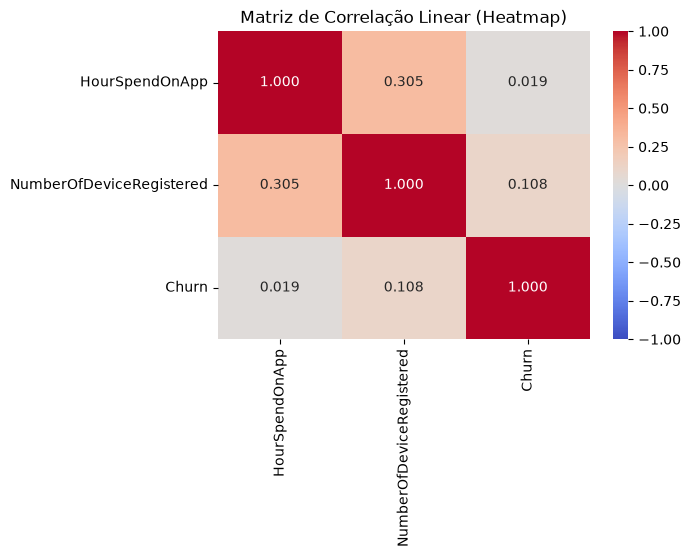

In [21]:
# Cria a matriz de correlação focada nas variáveis de interesse
matriz_corr = df[['HourSpendOnApp', 'NumberOfDeviceRegistered', 'Churn']].corr()

# Desenha o Mapa de Calor
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear (Heatmap)')
plt.show()

# Passo 5: Gráficos Boxplot (Distribuição dos Dados)
O Boxplot (Gráfico de Caixa) resume visualmente a distribuição dos dados em um desenho. 

### Como ler o Boxplot:
* **A linha do meio da caixa:** É a Mediana. Metade do grupo está acima, metade está abaixo.
* **O corpo da caixa (topo e base):** Concentra os 50% centrais dos usuários. É onde está a "grande massa" de comportamento.
* **As linhas que saem para cima e para baixo (antenas):** Mostram o limite do que é considerado normal (mínimo e máximo).
* **Pontinhos isolados fora das antenas (Outliers):** São os usuários com comportamento muito fora da curva (ex: alguém com dispositivos ou horas absurdamente acima do padrão).

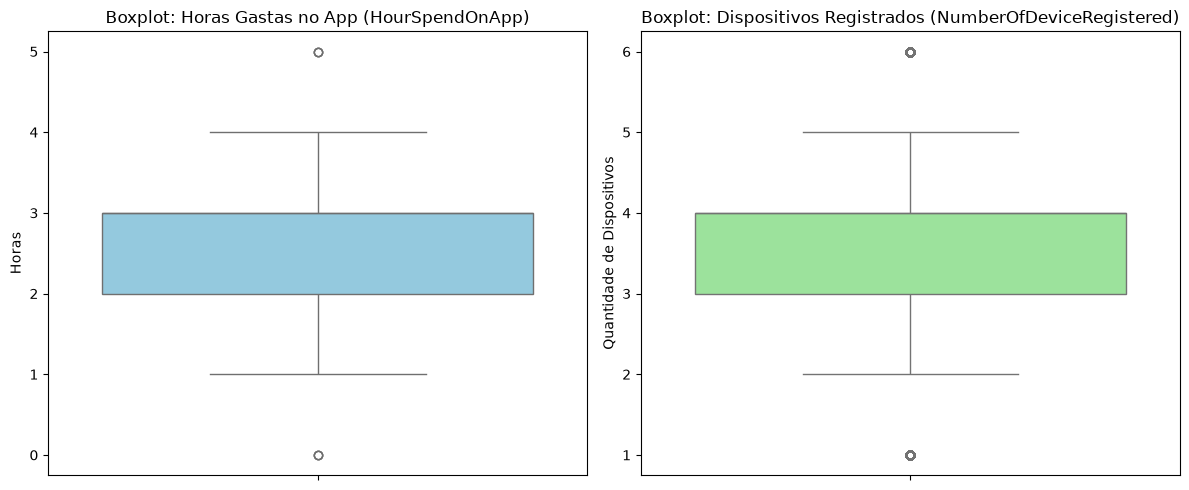

In [22]:
# Configura o tamanho da imagem dos gráficos
plt.figure(figsize=(12, 5))

# Boxplot para HourSpendOnApp
plt.subplot(1, 2, 1)
sns.boxplot(y=df['HourSpendOnApp'], color='skyblue')
plt.title('Boxplot: Horas Gastas no App (HourSpendOnApp)')
plt.ylabel('Horas')

# Boxplot para NumberOfDeviceRegistered
plt.subplot(1, 2, 2)
sns.boxplot(y=df['NumberOfDeviceRegistered'], color='lightgreen')
plt.title('Boxplot: Dispositivos Registrados (NumberOfDeviceRegistered)')
plt.ylabel('Quantidade de Dispositivos')

# Ajusta o espaçamento e mostra o gráfico na tela
plt.tight_layout()
plt.show()

# Passo 6: Cruzando as Variáveis com o Churn (Análise de Negócio)
Para tirar conclusões de negócio, este último passo divide os mesmos Boxplots anteriores em dois grupos lado a lado: 
* **Grupo 0:** Clientes que continuam ativos (Não deram Churn).
* **Grupo 1:** Clientes que cancelaram o serviço (Deram Churn).

Isso serve para comprovar visualmente a correlação. Se a caixa do Grupo 1 estiver bem mais alta do que a do Grupo 0, significa que o fator analisado impacta diretamente na decisão do cliente de abandonar a empresa.

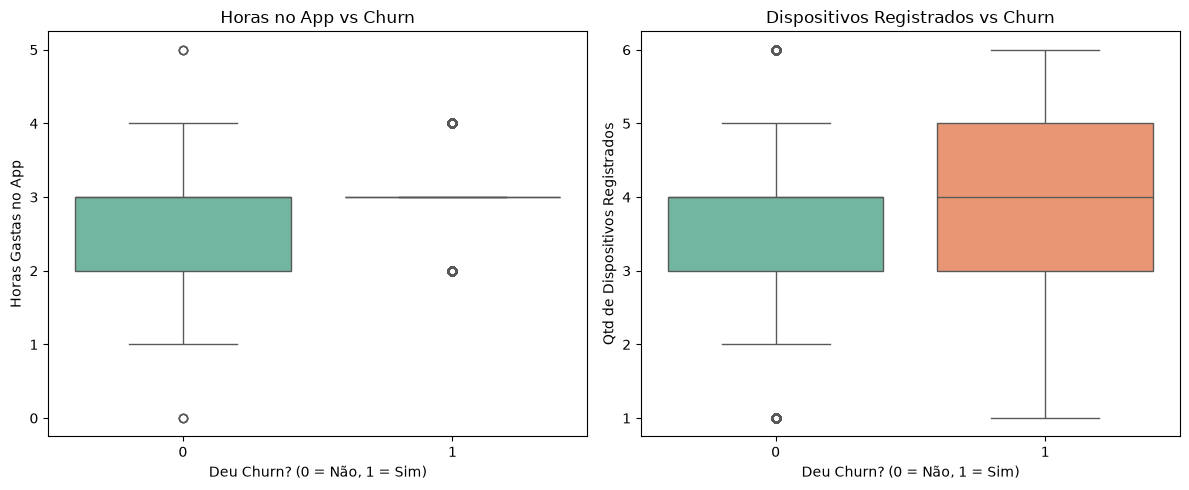

In [23]:
# Configura o tamanho da tela para os gráficos
plt.figure(figsize=(12, 5))

# 1. Gráfico de Horas no App separando por Churn
plt.subplot(1, 2, 1)
# Adicionamos hue='Churn' e legend=False para seguir a nova regra do Seaborn
sns.boxplot(x='Churn', y='HourSpendOnApp', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Horas no App vs Churn')
plt.xlabel('Deu Churn? (0 = Não, 1 = Sim)')
plt.ylabel('Horas Gastas no App')

# 2. Gráfico de Dispositivos Registrados separando por Churn
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='NumberOfDeviceRegistered', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Dispositivos Registrados vs Churn')
plt.xlabel('Deu Churn? (0 = Não, 1 = Sim)')
plt.ylabel('Qtd de Dispositivos Registrados')

# Ajusta o espaçamento entre os gráficos
plt.tight_layout()
plt.show()